# PBA SE 2026 - Programa Alfabetiza Sergipe
## Relatório 3.1: Monitoramento da Aprendizagem e Rotina Pedagógica

**Autor:** Fabrício Camacho

**Objetivo:** Analisar o progresso dos alfabetizandos e o cumprimento das metas operacionais estabelecidas no Termo de Referência.

**Data da Análise:** 11 de Maio de 2026.

## 1. Carregamento, Limpeza e Preparação dos Dados
### 1.1 Carregamento dos Dados
Aqui vamos carregar os dados através da importação de arquivo JSON e de arquivos retirados da plataforma de monitoramento da FGV. Consultaremos os dados através de snapshot, garantindo que os dados extraídos do JSON permaneçam os mesmos daqueles extraídos no dia da análise, evitando mudanças futuras dos dados que possam ocorrer no decorrer do programa.

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import os
import geopandas as gpd

# Importando arquivos separados
df_pedagogico = pd.read_csv(
    'data_files/public_data/dados_pedagogicos_11052026.csv', encoding='utf-8-sig')
df_turmas = pd.read_excel(
    'data_files/public_data/turmas_11052026.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'data_files/public_data/relatorios_turmas_diagnostica_11052026.xlsx')

# Criando diretório para salvar gráficos para relatório
dir_graficos = 'graficos_relatorio_3.1'
if not os.path.exists(dir_graficos):
    os.makedirs(dir_graficos)
    
# Garantindo cores de gráficos de acordo com paleta estabelecida
cores_pba = ["#005088", "#FFBB00", "#00843D", "#333333"]

# Imprimindo dados
print("-"*100)
print("df_pedagogico:")
print(df_pedagogico.info())
display(df_pedagogico.head())

print("-"*100)
print("df_turmas:")
print(df_turmas.info())
display(df_turmas.head())

print("-"*100)
print("df_relatorios_diagnostica:")
print(df_relatorios_diagnostica.info())
display(df_relatorios_diagnostica.head())


----------------------------------------------------------------------------------------------------
df_pedagogico:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3635 entries, 0 to 3634
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cpf                         3635 non-null   object 
 1   alfabetizando               3635 non-null   object 
 2   turma                       3635 non-null   object 
 3   status_alfabetizando        3635 non-null   object 
 4   dt_inicio_turma             3635 non-null   object 
 5   alfabetizador               3635 non-null   object 
 6   coordenador                 3635 non-null   object 
 7   qtd_aulas_dadas_turma       3635 non-null   int64  
 8   qtd_presenca_alfabetizando  3500 non-null   float64
 9   diag_entr_q1                2408 non-null   float64
 10  diag_entr_q2                2408 non-null   float64
 11  diag_entr_q3                240

,cpf,alfabetizando,turma,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,qtd_presenca_alfabetizando,diag_entr_q1,...,socio_said_q1,socio_said_q2,socio_said_q3,socio_said_q4,socio_said_q5,socio_said_q6,socio_said_q7,socio_said_q8,socio_said_q9,socio_said_result
0,105.473.268-07,Dr. Antony Nogueira,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,8,6.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,723.451.698-00,Dr. Rhavi Moura,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,8,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,190.856.423-70,Bella Sousa,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,8,7.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,027.168.345-71,Théo Pimenta,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,8,8.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,609.712.853-30,Gael Henrique das Neves,TURMA-28002970-0001,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,8,8.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------
df_turmas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Turma                   139 non-null    object 
 1   Escola                  139 non-null    object 
 2   Município               139 non-null    object 
 3   Qtd. alfabetizandos     139 non-null    int64  
 4   Coordenador             139 non-null    object 
 5   Alfabetizador           139 non-null    object 
 6   Data início             139 non-null    object 
 7   Data prevista de fim    139 non-null    object 
 8   Situação da turma       139 non-null    object 
 9   Data situação da turma  0 non-null      float64
 10  Data fim (máx.)         139 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 12.1+ KB
None


,Turma,Escola,Município,Qtd. alfabetizandos,Coordenador,Alfabetizador,Data início,Data prevista de fim,Situação da turma,Data situação da turma,Data fim (máx.)
0,TURMA-P0000206-0002,AOOS ASSOCIACAO OTAVIANO OLIVEIRA DE SOUZA,RIACHÃO DO DANTAS,23,Alexandre Pinto,Juliana Dias,27/04/2026,06/08/2026,Em funcionamento,NaN,13/08/2026
1,TURMA-P0000236-0001,ASSENTAMENTO EMÍLIA MARIA,SÃO CRISTÓVÃO,26,Luiz Otávio Vasconcelos,Ana Laura Castro,27/04/2026,24/07/2026,Em funcionamento,NaN,24/07/2026
2,TURMA-P0000248-0001,ASSENTAMENTO GIRASSOL,PORTO DA FOLHA,26,Ana Sophia Aragão,Camila Correia,27/04/2026,23/07/2026,Em funcionamento,NaN,23/07/2026
3,TURMA-P0000243-0001,ASSOCIAÇÃO ATLÉTICA DE ITABAIANA,ITABAIANA,27,Josué Leão,Bella Costa,27/04/2026,23/07/2026,Em funcionamento,NaN,23/07/2026
4,TURMA-P0000227-0002,ASSOCIAÇÃO - CENTRO COMUNITÁRIO CHE GUEVARA,LAGARTO,24,Heloisa Azevedo,Ana Lívia Macedo,27/04/2026,23/07/2026,Em funcionamento,NaN,23/07/2026


----------------------------------------------------------------------------------------------------
df_relatorios_diagnostica:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 5 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   ALFABETIZADOR                                                                          111 non-null    object 
 1   TURMA                                                                                  111 non-null    object 
 2   DATA DE LANÇAMENTO                                                                     111 non-null    object 
 3   Consolidação e análise dos dados realizadas por mecanismos de Inteligência Artificial  67 non-null     object 
 4   Observações do alfabetizador                                       

,ALFABETIZADOR,TURMA,DATA DE LANÇAMENTO,Consolidação e análise dos dados realizadas por mecanismos de Inteligência Artificial,Observações do alfabetizador
0,Thomas Cirino,TURMA-28010060-0001,07/05/2026,NaN,NaN
1,Sra. Liz Pastor,TURMA-28023315-0003,08/05/2026,NaN,NaN
2,Mateus da Cruz,TURMA-28020472-0001,07/05/2026,Por ser o primeiro contato de alguns alfabetiz...,NaN
3,Nicole Ramos,TURMA-28003500-0001,08/05/2026,"Eles estão aprendendo cada dia, devagar eles v...",NaN
4,Nicole Ramos,TURMA-28029372-0001,07/05/2026,"todos eles estão indo super bem , apesar de te...",NaN


**Observação:** É possível notar que os dados apresentam algumas características que precisam ser alteradas. Seguem elas:
- **Nome das colunas de arquivos XLSX:** Dados oriundos de arquivos extraídos da plataforma de monitoramento da FGV DGPE estão fora do padrão snake case e precisa ser alterados;
- **Dados tipo "object" de algumas colunas:** As colunas *"status_alfabetizando", "diag_entr_result", "socio_entr_result", "forma_1_result", "forma_2_result", "forma_3_result", "forma_4_result", "diag_said_result"* e *"socio_said_result"* em `df_pedagógico` apresentam dados categóricos. Por esse motivo, precisamos alterar o tipo de dado principalemnte para poupar espaço em memória durante a análise;
- **Dados com data:** A coluna "dt_inicio_turma" em *"df_pedagogico", "Data início", "Data prevista de fim", "Data situação da turma"* e *"Data fim (máx.)"* em `df_turmas`; e *"DATA DE LANÇAMENTO"* em `df_relatorios_diagnostica` apresentam dados de data e hora e precisam ser transformados em tal formato.
- **Resultados das Atividades:** Os resultados das atividades apresentam texto longo. Vamos criar uma coluna a mais para cada resultado contendo somente o nível em que o alfabetizando foi classificado.
- **Turma Modelo:** A turma **TURMA-P0000247-0001** foi criada para teste e possui dados falsos. Todos os dados dela precisam ser retirados para limpar a análise;
- **Alunos Evadidos:** A base de dados contém alfabetizandos que evadiram e não apresentam resultados de atividades. Dessa maneira, alfabetizandos com status **"EVADIDO"** na coluna *"status_alfabetizando"* não serão considerados na análise.

### 1.2 Preparação de Dados
Aqui vamos fazer a limpeza e preparação dos dados da seguinte forma:
- Alterar nome das colunas para padrão snake case;
- Tranformar dados tipo *object* em dados categóricos ou de data de acordo com o observado anteriormente;
- Criar colunas de resultados das atividades somente com o valor do Nível (N1, N2, N3 ou N4).

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    # Converte para minúsculo
    column_name = column_name.lower()
    
    # Remove acentos (Mantenha sua lógica ou use normalize)
    replacements = {
        'é': 'e', 'ã': 'a', 'ç': 'c', 'í': 'i', 'ó': 'o', 
        'ú': 'u', 'á': 'a', 'ê': 'e', 'ô': 'o', 'õ': 'o'
    }
    for char, replacement in replacements.items():
        column_name = column_name.replace(char, replacement)
    
    # Remove parênteses e pontos
    column_name = re.sub(r'[().]', '', column_name)
    
    # Substitui qualquer tipo de espaço por underscore
    # O \s+ pega um ou mais espaços de qualquer tipo (incluindo \xa0)
    column_name = re.sub(r'\s+', '_', column_name)
    
    return column_name.strip('_')

# Aplica a função to_snake_case aos nomes das colunas
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]

# Verificando resultados
print(df_turmas.columns)
print(df_relatorios_diagnostica.columns)


Index(['turma', 'escola', 'municipio', 'qtd_alfabetizandos', 'coordenador',
       'alfabetizador', 'data_inicio', 'data_prevista_de_fim',
       'situacao_da_turma', 'data_situacao_da_turma', 'data_fim_max'],
      dtype='object')
Index(['alfabetizador', 'turma', 'data_de_lancamento',
       'consolidacao_e_analise_dos_dados_realizadas_por_mecanismos_de_inteligencia_artificial',
       'observacoes_do_alfabetizador'],
      dtype='object')


In [3]:
# Transformando tipo de dados object em dados mais representativos (categorias e datas)
def transformar_dados_pba(df_pedag, df_turmas, df_diag=None):
    """
    Realiza a limpeza e transformação de tipos para o projeto Alfabetiza Sergipe.
    """
    # Transformação de Categóricos (df_pedagogico)
    cols_categoricas = [
        "status_alfabetizando", "diag_entr_result", "socio_entr_result", 
        "forma_1_result", "forma_2_result", "forma_3_result", 
        "forma_4_result", "diag_said_result", "socio_said_result"
    ]
    
    for col in cols_categoricas:
        if col in df_pedag.columns:
            df_pedag[col] = df_pedag[col].astype('category')
            
    # Transformação de Datas (df_pedagogico)
    if 'dt_inicio_turma' in df_pedag.columns:
        df_pedag['dt_inicio_turma'] = pd.to_datetime(df_pedag['dt_inicio_turma'], dayfirst=True, errors='coerce')
        
    # Transformação de Datas (df_turmas)
    cols_datas_turmas = ["data_inicio", "data_prevista_de_fim", "data_situacao_da_turma", "data_fim_max"]
    
    for col in cols_datas_turmas:
        if col in df_turmas.columns:
            df_turmas[col] = pd.to_datetime(df_turmas[col], dayfirst=True, errors='coerce')
            
    # Transformação de Datas (df_relatorios_diagnostica - se existir)
    if df_diag is not None and "DATA DE LANÇAMENTO" in df_diag.columns:
        df_diag["data_de_lancamento"] = pd.to_datetime(df_diag["data_de_lancamento"], dayfirst=True, errors='coerce')
        
    print("Transformação concluída com sucesso!")
    return df_pedag, df_turmas, df_diag

# Aplicando a função
df_pedagogico, df_turmas, df_relatorios_diagnostica = transformar_dados_pba(df_pedagogico, df_turmas, df_relatorios_diagnostica)

# Checando resultados
print(df_pedagogico.info())
print(df_turmas.info())
print(df_relatorios_diagnostica.info())


Transformação concluída com sucesso!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3635 entries, 0 to 3634
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         3635 non-null   object        
 1   alfabetizando               3635 non-null   object        
 2   turma                       3635 non-null   object        
 3   status_alfabetizando        3635 non-null   category      
 4   dt_inicio_turma             3635 non-null   datetime64[ns]
 5   alfabetizador               3635 non-null   object        
 6   coordenador                 3635 non-null   object        
 7   qtd_aulas_dadas_turma       3635 non-null   int64         
 8   qtd_presenca_alfabetizando  3500 non-null   float64       
 9   diag_entr_q1                2408 non-null   float64       
 10  diag_entr_q2                2408 non-null   float64       
 11  diag_entr_q3       

In [4]:
df_pedagogico['diag_entr_result'].value_counts()

diag_entr_result
N2 | Lê e registra algumas letras com ajuda, sem relação entre fala e escrita    827
N1 | Não reconhece as letras do alfabeto                                         699
N3 | Reconhece algumas letras do alfabeto                                        462
N4 | Identifica o número de sílabas de palavras com apoio                        420
Name: count, dtype: int64

In [5]:
# Extraindo somente os dados de nível em df_registros
# Criar o dicionário de mapeamento (Chave: Frase completa -> Valor: Apenas o Nível)
mapeamento_niveis = {
    'N1 | Não reconhece as letras do alfabeto': 'N1',
    'N2 | Lê e registra algumas letras com ajuda, sem relação entre fala e escrita': 'N2',
    'N3 | Reconhece algumas letras do alfabeto': 'N3',
    'N4 | Identifica o número de sílabas de palavras com apoio': 'N4'
}

# Criar a nova coluna usando o .map()
df_pedagogico['diag_entr_result_resum'] = df_pedagogico['diag_entr_result'].map(mapeamento_niveis)

# Transformar em tipo Categórico (ordenado)
# Isso é importante para que em gráficos o N1 venha antes do N2, etc.
niveis_ordenados = ['N1', 'N2', 'N3', 'N4']
df_pedagogico['diag_entr_result_resum'] = pd.Categorical(
    df_pedagogico['diag_entr_result_resum'], 
    categories=niveis_ordenados, 
    ordered=True
)

# Verificando os tipos de dados e informações das colunas
print(df_pedagogico.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3635 entries, 0 to 3634
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         3635 non-null   object        
 1   alfabetizando               3635 non-null   object        
 2   turma                       3635 non-null   object        
 3   status_alfabetizando        3635 non-null   category      
 4   dt_inicio_turma             3635 non-null   datetime64[ns]
 5   alfabetizador               3635 non-null   object        
 6   coordenador                 3635 non-null   object        
 7   qtd_aulas_dadas_turma       3635 non-null   int64         
 8   qtd_presenca_alfabetizando  3500 non-null   float64       
 9   diag_entr_q1                2408 non-null   float64       
 10  diag_entr_q2                2408 non-null   float64       
 11  diag_entr_q3                2408 non-null   float64     

### 1.3 Limpeza e Organização de Dados
Aqui retiraremos alguns dados e adicionar informações para que a análise ocorra corretamente. Os seguintes dados serão retirados:
- Dados da turma **TURMA-P0000247-0001**, que foi criada para teste e não apresenta dados reais;
- Dados de alfabetizandos com status **EVADIDO**;
- Adicionar infirmação de município ao `df_pedagogico`, juntando com as informações de `df_turma`;
- Retirar valores vazios de alfabetizandos sem resultados


In [6]:
# Verificando o tamanho antes da filtragem
print(f"Registros antes da filtragem: {len(df_pedagogico)}")

# 2. Aplicando os filtros
# Filtro: Turma diferente de 'TURMA-P0000247-0001' E Status diferente de 'EVADIDO'
def filtrar_turmas(df):
    """
    Filtra o DataFrame verificando se as colunas necessárias existem.
    """
    # Criamos uma cópia para evitar o SettingWithCopyWarning
    df_resultado = df.copy()
    
    # 1. Verificação da coluna 'turma'
    if 'turma' in df_resultado.columns:
        df_resultado = df_resultado[df_resultado['turma'] != 'TURMA-P0000247-0001']
    else:
        print("Aviso: Coluna 'turma' não encontrada. Filtro de turma não aplicado.")
    
    # 2. Verificação da coluna 'status_alfabetizando'
    if 'status_alfabetizando' in df_resultado.columns:
        df_resultado = df_resultado[df_resultado['status_alfabetizando'] != 'EVADIDO']
    else:
        print("Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.")
    
    return df_resultado

# Aplicando a função
df_pedagogico = filtrar_turmas(df_pedagogico)
df_turmas = filtrar_turmas(df_turmas)
df_relatorios_diagnostica = filtrar_turmas(df_relatorios_diagnostica)

# 3. Verificando o tamanho após a filtragem
print(f"Registros após a filtragem: {len(df_pedagogico)}")

# 4. Validando se a turma ainda existe no dataset
check_turma = 'TURMA-P0000247-0001' in df_pedagogico['turma'].unique()
print(f"A turma TURMA-P0000247-0001 ainda está presente? {check_turma}")


Registros antes da filtragem: 3635
Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.
Aviso: Coluna 'status_alfabetizando' não encontrada. Filtro de evasão não aplicado.
Registros após a filtragem: 3016
A turma TURMA-P0000247-0001 ainda está presente? False


In [7]:
# Adicionando informações de município aos dados pedagógicos de df_pedagogico
# Criando o DataFrame de referência apenas com as colunas necessárias
df_dados_turmas = df_turmas[['turma', 'municipio', 'escola']].drop_duplicates()

# Realizando o merge
# Unimos pela coluna 'turma' (df_pedagógico) e 'turma' (df_turmas)
df_pedagogico = pd.merge(
    df_pedagogico, 
    df_dados_turmas, 
    on='turma',  
    how='left'
)

# Retirando linhas de alfabetizandos sem resultados
df_pedagogico = df_pedagogico.dropna(subset=['diag_entr_result']).copy()

# Verificação: conferir se há alunos sem município atribuído
nas_municipio = df_pedagogico['municipio'].isna().sum()
print(f"Alunos sem município após o join: {nas_municipio}")

if nas_municipio > 0:
    print("Aviso: Existem turmas no pedagógico que não constam no cadastro de turmas.")


Alunos sem município após o join: 0


In [8]:
df_pedagogico_na = df_pedagogico[df_pedagogico['diag_entr_result'].isna()]
print(df_pedagogico_na.info())

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 68 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         0 non-null      object        
 1   alfabetizando               0 non-null      object        
 2   turma                       0 non-null      object        
 3   status_alfabetizando        0 non-null      category      
 4   dt_inicio_turma             0 non-null      datetime64[ns]
 5   alfabetizador               0 non-null      object        
 6   coordenador                 0 non-null      object        
 7   qtd_aulas_dadas_turma       0 non-null      int64         
 8   qtd_presenca_alfabetizando  0 non-null      float64       
 9   diag_entr_q1                0 non-null      float64       
 10  diag_entr_q2                0 non-null      float64       
 11  diag_entr_q3                0 non-null      float64       
 12  diag_entr_q

## 2. Análise do Perfil Inicial e Desempenho Pedagógico

Nesta etapa, realizamos a análise quantitativa da presença do **Programa Alfabetiza Sergipe 2026** nos municípios e o perfil técnico de entrada dos alfabetizandos. 

O foco aqui é duplo:
1.  **Monitoramento Operacional:** Quantificar o alcance do programa (Turmas e Alunos) por território.
2.  **Diagnóstico Pedagógico:** Analisar os níveis de alfabetização (N1 a N4) para embasar as estratégias de ensino do Relatório 3.1.

### 2.1 Cobertura Territorial: Turmas e Alunos por Município

Para o monitoramento da rotina de alfabetização, é essencial cruzar o número de turmas ativas com o volume de alunos. Esta análise permite identificar a densidade do programa em cada localidade e verificar a conformidade com as metas de atendimento.


In [9]:
# Configurações de estilo e paleta
sns.set_style("whitegrid", {'axes.grid' : False}) # Grid personalizado

# Consolidação de Dados por Município
# Criando um resumo por município a partir do df_turmas
resumo_municipios = df_turmas.groupby('municipio').agg(
    qtd_turmas=('turma', 'count'),
    total_alunos=('qtd_alfabetizandos', 'sum')
).sort_values(by='total_alunos', ascending=False)

# Salvando arquivo
nome_do_arquivo_1 = 'turmas_e_alfabetizandos_por_municipio.xlsx'
caminho_excel_1 = os.path.join(dir_graficos, nome_do_arquivo_1)
resumo_municipios.to_excel(caminho_excel_1, index=False)

print(f"Planilha salva com sucesso em: {caminho_excel_1}")

# Imprimindo resultados
print(f'Quantidade de turmas no programa: {resumo_municipios["qtd_turmas"].sum()}')
print(f'Quantidade de municípios atendidos: {resumo_municipios.shape[0]}')
print(f'Quantidade de turmas com resultados de atividade diagnóstica: {df_pedagogico["turma"].nunique()}')
print(f'Quantidade de municipios com turmas com resultados de atividade diagnóstica: {df_pedagogico["municipio"].nunique()}')
print("Resumo de Distribuição por Município:")
display(resumo_municipios)


Planilha salva com sucesso em: graficos_relatorio_3.1/turmas_e_alfabetizandos_por_municipio.xlsx
Quantidade de turmas no programa: 138
Quantidade de municípios atendidos: 31
Quantidade de turmas com resultados de atividade diagnóstica: 126
Quantidade de municipios com turmas com resultados de atividade diagnóstica: 31
Resumo de Distribuição por Município:


,qtd_turmas,total_alunos
municipio,,
ARACAJU,18,391
LAGARTO,17,362
PORTO DA FOLHA,10,257
SIMÃO DIAS,13,256
ITABAIANA,9,223
SÃO CRISTÓVÃO,7,145
MONTE ALEGRE DE SERGIPE,6,138
ESTÂNCIA,6,126
ITABAIANINHA,5,116


Gráfico salvo com sucesso em: graficos_relatorio_3.1/1_numero_de_turmas_e_alunos_por_municipio.png


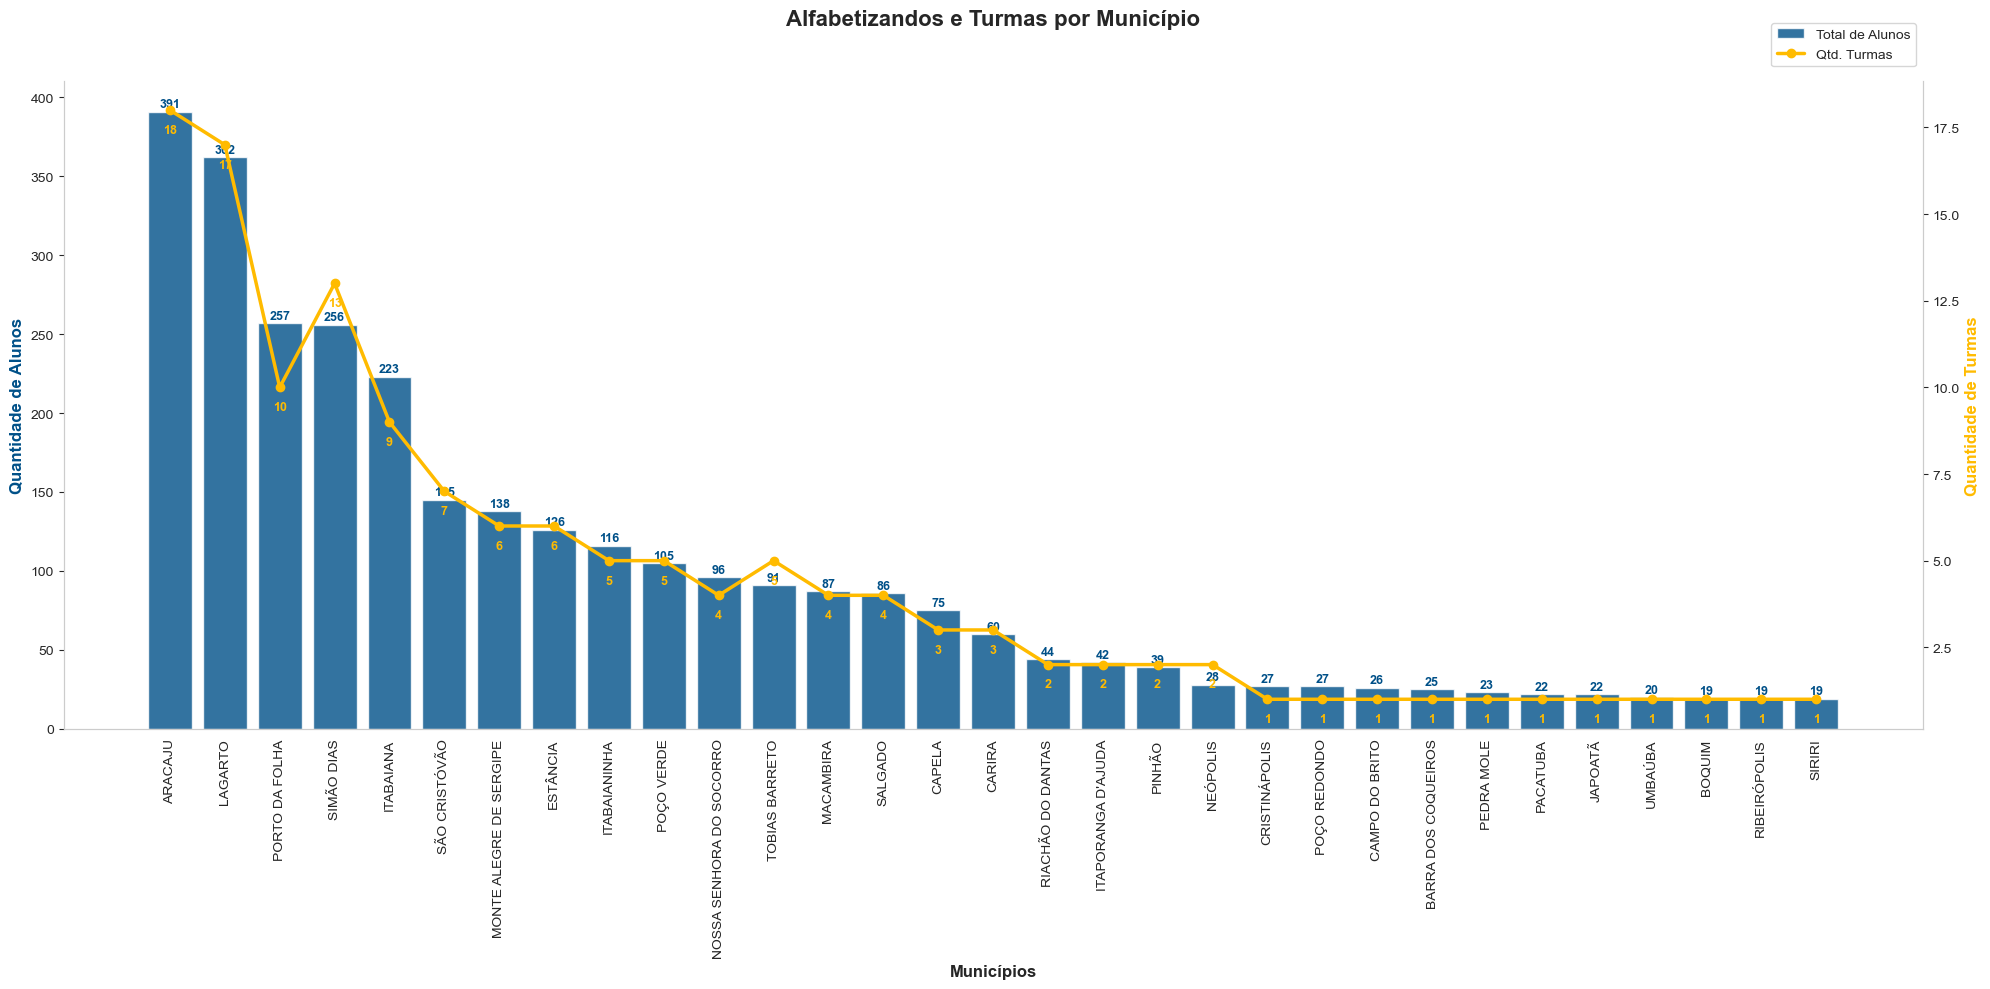

In [10]:
# Preparação dos dados para criação de gráfico de turmas e alfabetizandos(Garantindo que todos os municípios sejam incluídos)
resumo_completo = resumo_municipios.copy() # Usando o DF que criamos anteriormente
x_labels = resumo_completo.index

# Configuração do gráfico
fig, ax1 = plt.subplots(figsize=(20, 10)) # Aumentamos a largura para caber todos

# --- EIXO 1: ALUNOS (BARRAS) ---
barras = ax1.bar(x_labels, resumo_completo['total_alunos'], color="#005088", label='Total de Alunos', alpha=0.8)
ax1.set_ylabel('Quantidade de Alunos', color="#005088", fontsize=12, fontweight='bold')
ax1.set_xlabel('Municípios', fontsize=12, fontweight='bold')

# Rótulos das barras (Alunos) - No topo das barras
ax1.bar_label(barras, padding=1, color="#005088", fontweight='bold', fontsize=9)

# Configuração do Eixo X para mostrar TODOS os nomes
ax1.set_xticks(range(len(x_labels)))
ax1.set_xticklabels(x_labels, rotation=90, fontsize=10)

# --- EIXO 2: TURMAS (LINHA) ---
ax2 = ax1.twinx()
linha = ax2.plot(x_labels, resumo_completo['qtd_turmas'], color="#FFBB00", marker='o', 
                 linewidth=2.5, markersize=6, label='Qtd. Turmas')
ax2.set_ylabel('Quantidade de Turmas', color="#FFBB00", fontsize=12, fontweight='bold')

# Rótulos da linha (Turmas) - ABAIXO do ponto e na COR #FFBB00
for i, valor in enumerate(resumo_completo['qtd_turmas']):
    ax2.text(i, valor - 0.4, str(int(valor)), color="#FFBB00", 
             ha='center', va='top', fontweight='bold', fontsize=9)

# Unificando as legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right', bbox_to_anchor=(1, 1.1))

plt.title('Alfabetizandos e Turmas por Município', fontsize=16, pad=40, fontweight='bold')
plt.tight_layout()
sns.despine(right=False)

# Salvando o gráfico em dir_graficos
nome_grafico_1 = '1_numero_de_turmas_e_alunos_por_municipio.png'
caminho_grafico_1 = os.path.join(dir_graficos, nome_grafico_1)

plt.savefig(caminho_grafico_1, dpi=300, bbox_inches='tight') # dpi=300 garante alta qualidade para relatórios/impressão
print(f"Gráfico salvo com sucesso em: {caminho_grafico_1}")
plt.show()


## 3. Avaliação Pedagógica e Resultados do Diagnóstico Inicial

Este capítulo detalha os resultados obtidos através da aplicação dos diagnósticos de entrada. De acordo com o **Termo de Referência do PBA SE 2026**, o monitoramento da rotina de alfabetização deve partir de uma base sólida de dados que identifique o perfil de proficiência dos alfabetizandos ativos.

A análise a seguir foca na distribuição dos alunos pelos níveis **N1 a N4**, permitindo que a coordenação pedagógica ajuste o material didático e as formações de acordo com a realidade de cada turma. 

### 3.1 Níveis de Alfabetização (Entrada)

Para fins deste relatório, a classificação segue os critérios estabelecidos pela SEED:
* **N1:** Não reconhece as letras do alfabeto.
* **N2** Lê e registra algumas letras com ajuda, sem relação entre fala e escrita.
* **N3:** Reconhece algumas letras do alfabeto.
* **N4:** Identifica o número de sílabas de palavras com apoio.


Gráfico salvo com sucesso em: graficos_relatorio_3.1/2_alfabetizandos_por_nivel_geral.png


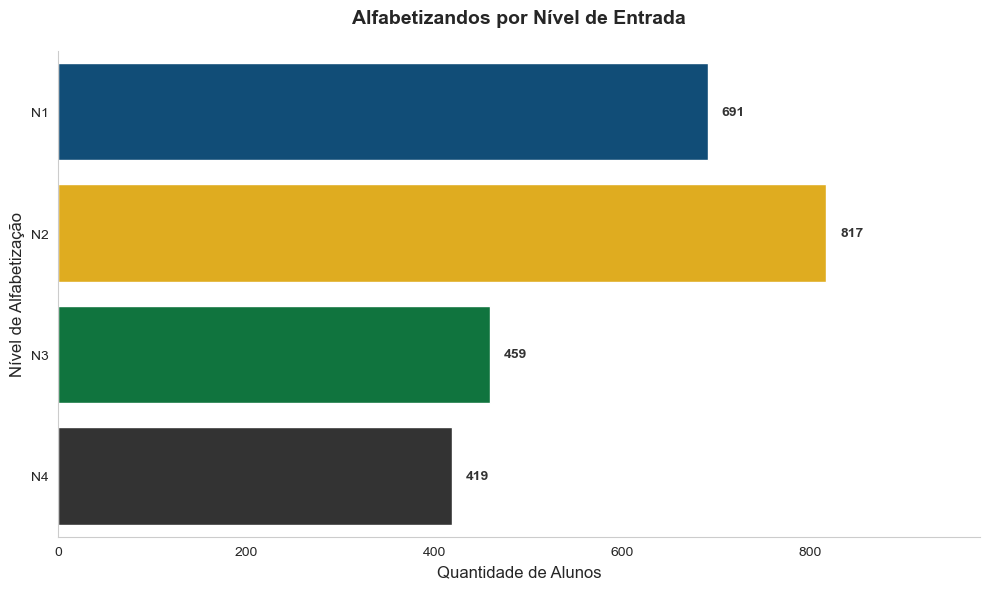

In [11]:
# Gerando dados para gráfico de níveis
resultado_diag_entrada_geral = df_pedagogico.groupby(['diag_entr_result_resum'], observed=False)['cpf'].count().reset_index()
resultado_diag_entrada_geral.columns = ['resultado_diag_entrada', 'numero_alfabetizandos']

# 1. Configuração do gráfico (usando subplots para maior controle)
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Criação do gráfico de barras
sns.barplot(
    data=resultado_diag_entrada_geral, 
    x='numero_alfabetizandos', 
    y='resultado_diag_entrada', 
    palette=cores_pba,
    hue='resultado_diag_entrada',
    ax=ax
)

# 3. Adicionando os rótulos de dados (valores absolutos) no topo das barras
# Iteramos sobre cada container para garantir que nenhum nível fique sem o valor
for container in ax.containers:
    ax.bar_label(container, padding=10, fontweight='bold', color='#333333')

# 4. Ajustes de títulos e limites
ax.set_title('Alfabetizandos por Nível de Entrada', 
             fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Quantidade de Alunos', fontsize=12)
ax.set_ylabel('Nível de Alfabetização', fontsize=12)

# Aumentamos o limite do eixo X para os números não serem cortados
ax.set_xlim(0, resultado_diag_entrada_geral['numero_alfabetizandos'].max() * 1.2)

sns.despine()
plt.tight_layout()

# Salvando o gráfico em dir_graficos
nome_grafico_2 = '2_alfabetizandos_por_nivel_geral.png'
caminho_grafico_2 = os.path.join(dir_graficos, nome_grafico_2)

plt.savefig(caminho_grafico_2, dpi=300, bbox_inches='tight') # dpi=300 garante alta qualidade para relatórios/impressão
print(f"Gráfico salvo com sucesso em: {caminho_grafico_2}")
plt.show()


### 3.2 Diagnóstico por Município (Geração de Gráficos Individuais)

Para subsidiar as equipes técnicas locais, automatizamos a geração de gráficos de desempenho para cada um dos municípios parceiros. 

**Processo de Automação:**
1. O código identifica todos os municípios únicos na base de dados.
2. Filtra os alfabetizandos ativos de cada localidade.
3. Gera um gráfico horizontal respeitando a identidade visual do PBA.
4. Salva o arquivo `.png` no diretório de saída (`dir_graficos`) para inclusão automática nos relatórios municipais.


In [12]:
# Lista de municípios únicos
municipios = sorted(df_pedagogico['municipio'].unique())

# Definimos a ordem fixa para que o gráfico SEMPRE reserve espaço para as 4 barras
# Isso evita que o gráfico "alargue" as barras quando um município tem apenas 1 ou 2 níveis
ordem_fixa = ['N1', 'N2', 'N3', 'N4'] 

print(f"Iniciando a geração de gráficos padronizados para {len(municipios)} municípios...")

for muni in municipios:
    df_muni = df_pedagogico[df_pedagogico['municipio'] == muni]
    
    # Agrupar dados
    resultado_muni = df_muni.groupby(['diag_entr_result_resum'], observed=False)['cpf'].count().reset_index()
    resultado_muni.columns = ['resultado_diag_entrada', 'numero_alfabetizandos']
    
    # Mantemos o figsize similar ao seu gráfico geral para proporção
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # --- AJUSTE DE ESPESSURA ---
    sns.barplot(
        data=resultado_muni, 
        x='numero_alfabetizandos', 
        y='resultado_diag_entrada', 
        palette=cores_pba,
        hue='resultado_diag_entrada', # Colorir a barra com base no resultado
        order=ordem_fixa, # ESSENCIAL: Garante que o eixo Y tenha sempre 4 posições
        height=0.8,       # FIXA A ESPESSURA: 0.8 é a largura padrão do Seaborn
        ax=ax
    )
    
    # Adicionar rótulos (Loop em todos os containers)
    for container in ax.containers:
        ax.bar_label(container, padding=10, fontweight='bold', color='#333333')
    
    # Títulos e Estética (Seguindo seu padrão)
    ax.set_title(f'Perfil de Entrada: {muni}', fontsize=14, pad=15, fontweight='bold', color="#005088")
    ax.set_xlabel('Quantidade de Alunos', fontsize=10)
    ax.set_ylabel('Nível', fontsize=10)
    
    # Ajuste de margem (1.4 garante espaço para o rótulo à direita)
    max_val = resultado_muni['numero_alfabetizandos'].max()
    ax.set_xlim(0, (max_val * 1.4) if max_val > 0 else 10)
    
    sns.despine()
    plt.tight_layout()
    
    # Salvando o arquivo no diretório dir_graficos
    nome_arquivo = f"diag_entrada_{muni.lower().replace(' ', '_')}.png"
    caminho_salvamento = os.path.join(dir_graficos, nome_arquivo)
    
    plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
    plt.close(fig)

print(f"Sucesso! Gráficos com espessura padronizada salvos em: {dir_graficos}")


Iniciando a geração de gráficos padronizados para 31 municípios...
Sucesso! Gráficos com espessura padronizada salvos em: graficos_relatorio_3.1


# 4. Monitoramento de Metas de Enturmação (Conformidade com o TR)

O Termo de Referência do PBA SE 2026 estipula limites para a formação das turmas, visando garantir a qualidade pedagógica e a otimização dos recursos. 

**Parâmetros Analisados:**
* **Limite Mínimo:** 14 alunos (referência para zona urbana).
* **Limite Máximo:** 27 alunos por turma.

Nesta seção, avaliamos a média de alfabetizandos por turma em cada município parceiro. Municípios fora desta faixa exigirão justificativas técnicas (ex: turmas em áreas rurais de difícil acesso, que permitem mínimo de 7 alunos) ou readequação de enturmação.

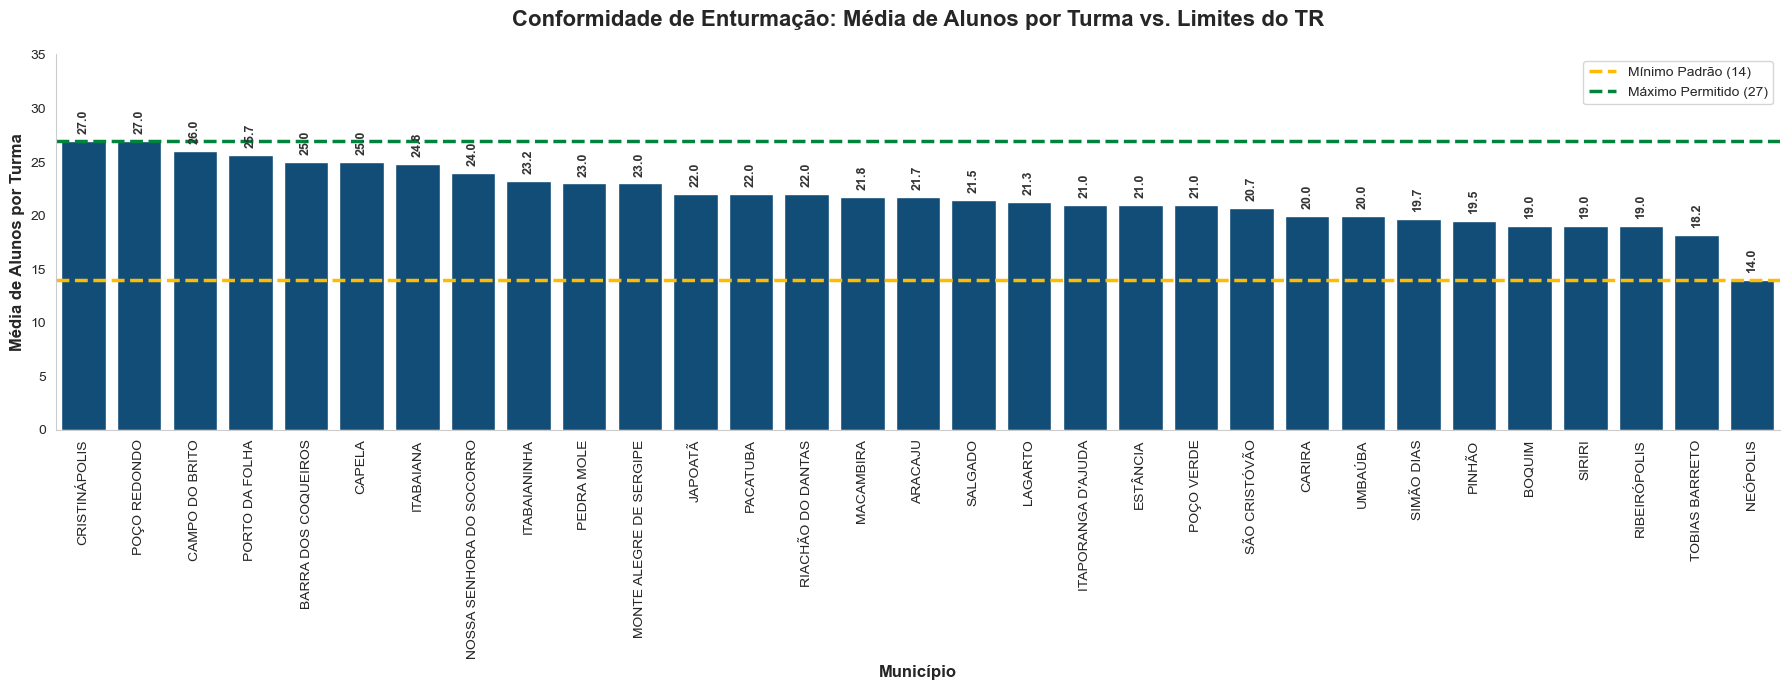

Gráfico de metas de enturmação gerado e salvo com sucesso.


In [13]:
# Agrupamento e cálculo da média de alunos por turma por município
resumo_metas = df_turmas.groupby('municipio', observed=True).agg(
    total_turmas=('turma', 'count'),
    media_alunos_turma=('qtd_alfabetizandos', 'mean')
).reset_index()

# Ordenando do maior para o menor para facilitar a visualização
resumo_metas = resumo_metas.sort_values('media_alunos_turma', ascending=False)

# Configuração do Gráfico
fig, ax = plt.subplots(figsize=(18, 7))

# Usaremos a cor Azul (#005088) como padrão
sns.barplot(
    data=resumo_metas, 
    x='municipio', 
    y='media_alunos_turma', 
    color=cores_pba[0], 
    ax=ax
)

# Adicionando as Linhas de Meta do TR
ax.axhline(14, color=cores_pba[1], linestyle='--', linewidth=2.5, label='Mínimo Padrão (14)') # Amarelo
ax.axhline(27, color=cores_pba[2], linestyle='--', linewidth=2.5, label='Máximo Permitido (27)') # Verde

# Adicionando os Rótulos de Dados nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontweight='bold', color='#333333', fontsize=9, rotation=90)

# Ajustes Estéticos
ax.set_title('Conformidade de Enturmação: Média de Alunos por Turma vs. Limites do TR', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Município', fontsize=12, fontweight='bold')
ax.set_ylabel('Média de Alunos por Turma', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Ajuste do limite Y para não cortar os rótulos
ax.set_ylim(0, resumo_metas['media_alunos_turma'].max() * 1.3)

ax.legend(loc='upper right', frameon=True)
sns.despine()
plt.tight_layout()

# Salvando o Gráfico
nome_grafico_4 = '3_metas_enturmacao_municipio.png'
caminho_grafico_4 = os.path.join(dir_graficos, nome_grafico_4)
plt.savefig(caminho_grafico_4, dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico de metas de enturmação gerado e salvo com sucesso.")


# 5. Monitoramento de Frequência e Risco de Evasão

A retenção do alfabetizando é um dos maiores desafios da EJA (Educação de Jovens e Adultos). O monitoramento da frequência é o indicador antecedente primário para o risco de evasão.

**Critério de Análise:**
* O índice mínimo de aceitação padrão em programas educacionais do estado costuma ser de **75% de frequência**. 
* Abaixo desse limite, a coordenação local deve acionar a estratégia de busca ativa.

*Nota: A taxa é calculada dividindo o número de presenças computadas pela quantidade de aulas dadas na turma até o momento do snapshot.*

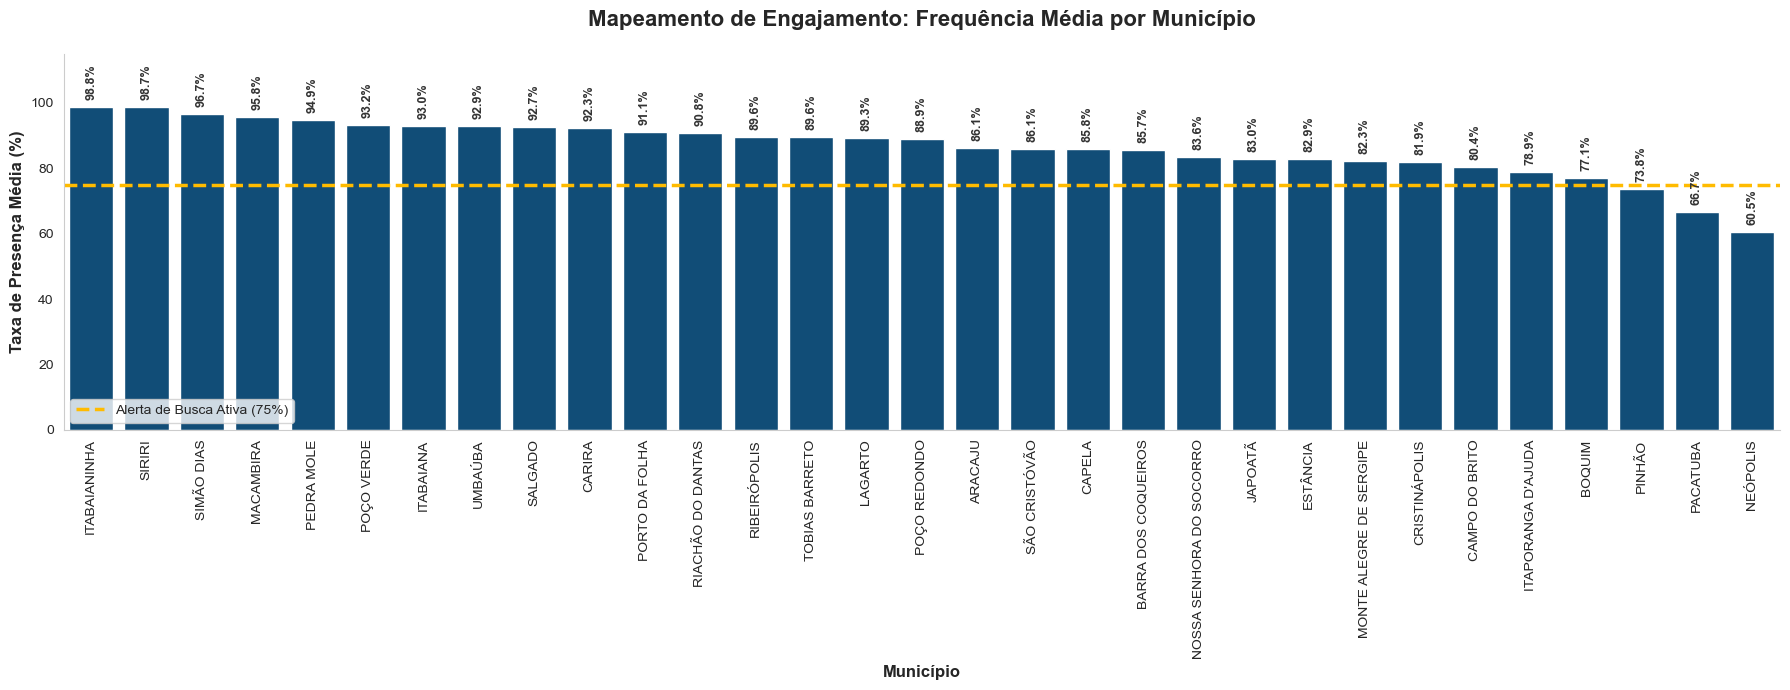

ALERTA EXECUTIVO:
Total de alunos com frequência abaixo de 75%: 353 (14.8% da amostra ativa).
Recomenda-se exportar a lista nominal destes alfabetizandos para os coordenadores locais.


In [14]:
# Tratamento e Cálculo da Taxa de Frequência
# Usamos np.where para evitar erro de divisão por zero caso haja turmas recém-criadas com 0 aulas dadas
df_pedagogico['taxa_frequencia'] = np.where(
    df_pedagogico['qtd_aulas_dadas_turma'] > 0,
    (df_pedagogico['qtd_presenca_alfabetizando'] / df_pedagogico['qtd_aulas_dadas_turma']) * 100,
    0
)

# Agrupamento por município para ver a frequência média
freq_muni = df_pedagogico.groupby('municipio', observed=True)['taxa_frequencia'].mean().reset_index()
freq_muni = freq_muni.sort_values('taxa_frequencia', ascending=False)

# Configuração do Gráfico
fig, ax = plt.subplots(figsize=(18, 7))

# Gráfico de barras na cor Azul institucional
sns.barplot(
    data=freq_muni, 
    x='municipio', 
    y='taxa_frequencia', 
    color=cores_pba[0], 
    ax=ax
)

# Linha de Alerta de Frequência (75%)
ax.axhline(75, color=cores_pba[1], linestyle='--', linewidth=2.5, label='Alerta de Busca Ativa (75%)') # Amarelo

# Adicionando os Rótulos de Dados
for container in ax.containers:
    # Usamos fmt='%.1f%%' para adicionar o símbolo de porcentagem no gráfico
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold', color='#333333', fontsize=9, rotation=90)

# Ajustes Estéticos
ax.set_title('Mapeamento de Engajamento: Frequência Média por Município', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Município', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Presença Média (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Forçamos o eixo Y a ir até 115 para caber bem os rótulos de 100%
ax.set_ylim(0, 115) 

ax.legend(loc='lower left', frameon=True)
sns.despine()
plt.tight_layout()

# Salvando o Gráfico
nome_grafico_5 = ('4_frequencia_media_municipio.png')
caminho_grafico_5 = os.path.join(dir_graficos, nome_grafico_5)
plt.savefig(caminho_grafico_5, dpi=300, bbox_inches='tight')
plt.show()

# Extração Executiva: Contagem de Alunos Críticos
alunos_risco = df_pedagogico[df_pedagogico['taxa_frequencia'] < 75].shape[0]
percentual_risco = (alunos_risco / len(df_pedagogico)) * 100

print(f"ALERTA EXECUTIVO:")
print(f"Total de alunos com frequência abaixo de 75%: {alunos_risco} ({percentual_risco:.1f}% da amostra ativa).")
print("Recomenda-se exportar a lista nominal destes alfabetizandos para os coordenadores locais.")


# 6. Distribuição Espacial da Aprendizagem (Mapa de Calor)

Para refinar o planejamento estratégico, este item apresenta uma visualização geoespacial (mapa coroplético) focada nos alfabetizandos que se encontram nos níveis mais altos do diagnóstico de entrada (**N3 e N4**).

Municípios com cores mais quentes indicam uma alta proporção de alunos que já possuem habilidades de leitura silábica ou silábico-alfabética. Isso sinaliza para a coordenação pedagógica que tais regiões podem necessitar de acervos literários mais avançados, enquanto os municípios em cores claras necessitam de forte intervenção fonológica.

> **Metodologia:** Calculamos o percentual de alunos N3 e N4 em relação ao total de alunos ativos de cada município e cruzamos com a malha territorial (Shapefile) do estado de Sergipe.

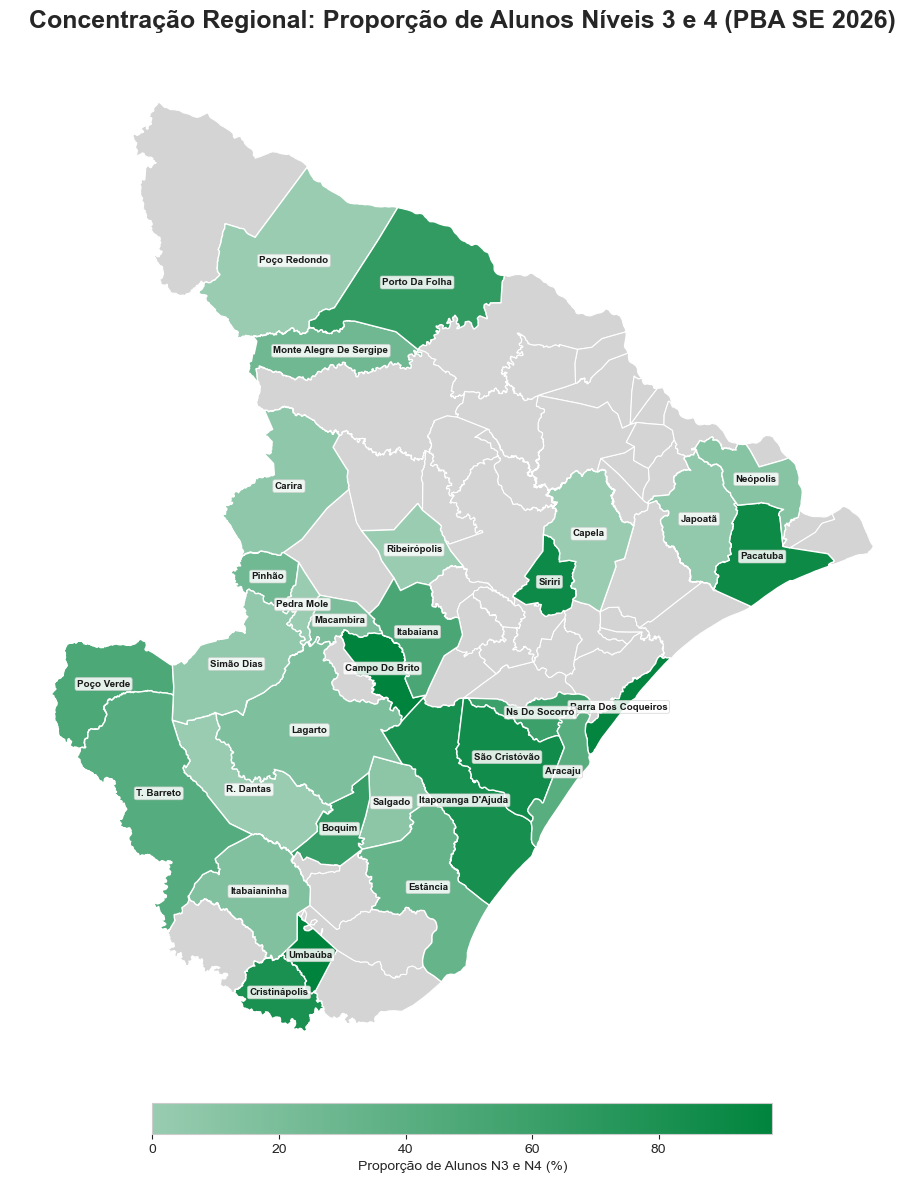

Mapa de Calor gerado e salvo com sucesso!


In [15]:
# Funções de tratamento de texto
def padronizar_nomes(texto):
    return (
        texto.str.upper()
        .str.normalize('NFKD')
        .str.encode('ascii', errors='ignore')
        .str.decode('utf-8')
        .str.replace(r"\b(DE|DA|DO|DAS|DOS)\b", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

def abreviar_nome(nome):
    substituicoes = {
        "NOSSA SENHORA": "NS",
        "N.S.": "NS",
        "TOBIAS BARRETO": "T. BARRETO",
        "RIACHÃO DO DANTAS": "R. DANTAS",
        "SANTA LUZIA DO ITANHY": "ST LUZIA ITANHY", # Removido o 'ª' para evitar erro de encoding no plot
        "SAO FRANCISCO": "S. FRANCISCO"
    }
    nome = str(nome).upper()
    for original, abreviado in substituicoes.items():
        nome = nome.replace(original, abreviado)
    return nome.title()

# PREPARAÇÃO DOS DADOS PEDAGÓGICOS
# A. Total de alunos ativos por município
total_muni = df_pedagogico.groupby('municipio', observed=True)['cpf'].count().reset_index()
total_muni.columns = ['municipio', 'total_alunos']

# B. Filtrar apenas alunos N3 e N4 e contar
df_n3_n4 = df_pedagogico[df_pedagogico['diag_entr_result_resum'].isin(['N3', 'N4'])]
n3_n4_muni = df_n3_n4.groupby('municipio', observed=True)['cpf'].count().reset_index()
n3_n4_muni.columns = ['municipio', 'total_n3_n4']

# C. Juntar e calcular o percentual
df_mapa_dados = pd.merge(total_muni, n3_n4_muni, on='municipio', how='left').fillna(0)
df_mapa_dados['pct_n3_n4'] = (df_mapa_dados['total_n3_n4'] / df_mapa_dados['total_alunos']) * 100

# Aplicar a função de padronização no dataset pedagógico
df_mapa_dados['nome_padrao'] = padronizar_nomes(df_mapa_dados['municipio'])

# 3. CARREGAMENTO E JOIN ESPACIAL (SHAPEFILE)
caminho_shp = 'data_files/SE_Municipios_2024/SE_Municipios_2024.shp'
gdf_se = gpd.read_file(caminho_shp)

# ATENÇÃO: Os shapefiles do IBGE geralmente usam 'NM_MUN' como nome da coluna do município.
# Se o seu shapefile tiver outro nome (ex: 'NOME', 'MUNICÍPIO'), altere a linha abaixo!
coluna_nome_shapefile = 'NM_MUN'

# Padronizar nomes no Shapefile
gdf_se['nome_padrao'] = padronizar_nomes(gdf_se[coluna_nome_shapefile])

# Fazer o Join Espacial (Merge do Shapefile com os dados do programa)
gdf_mapa = gdf_se.merge(df_mapa_dados, on='nome_padrao', how='left')

# Preencher municípios que não participam do programa (NaN) com -1 para pintá-los de cinza
gdf_mapa['pct_n3_n4'] = gdf_mapa['pct_n3_n4'].fillna(-1)

# Aplicar abreviação para os rótulos do mapa
gdf_mapa['nome_label'] = gdf_mapa[coluna_nome_shapefile].apply(abreviar_nome)

# 4. PLOTAGEM DO MAPA DE CALOR
fig, ax = plt.subplots(1, 1, figsize=(16, 16))

# A. Criar o Colormap (Ajuste de Saturação para o Verde)
# Começamos com um Verde Sálvia denso (#99CCB1) para evitar o aspecto pálido
# e terminamos no Verde Institucional PBA (#00843D)
cores_gradiente = ['#99CCB1', '#00843D'] 
cmap_verde_pba = LinearSegmentedColormap.from_list('Verde_PBA_Forte', cores_gradiente)

# B. Plotar municípios INATIVOS (Cinza de contraste)
gdf_mapa[gdf_mapa['pct_n3_n4'] == -1].plot(
    ax=ax, color='#D4D4D4', edgecolor='white', linewidth=0.8
)

# C. Definir limite de contraste (Cortando outliers)
dados_ativos = gdf_mapa[gdf_mapa['pct_n3_n4'] >= 0]
limite_maximo_cor = dados_ativos['pct_n3_n4'].quantile(0.95)

# D. Plotar municípios ATIVOS (Com o degradê verde)
mapa_plot = dados_ativos.plot(
    column='pct_n3_n4',
    cmap=cmap_verde_pba,  # Aplicando a nova paleta verde
    ax=ax,
    edgecolor='white',
    linewidth=1.0, 
    vmax=limite_maximo_cor, 
    legend=True,
    legend_kwds={
        'label': "Proporção de Alunos N3 e N4 (%)", 
        'orientation': "horizontal", 
        'shrink': 0.5,
        'pad': 0.02
    }
)

# E. Adicionar rótulos
for idx, row in dados_ativos.iterrows():
    centroide = row.geometry.centroid
    
    ax.annotate(
        text=row['nome_label'], 
        xy=(centroide.x, centroide.y), 
        ha='center', va='center',
        fontsize=7, color='#1A1A1A', fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='#CCCCCC', linewidth=0.5, boxstyle='round,pad=0.2')
    )

# F. Estética final
ax.set_title('Concentração Regional: Proporção de Alunos Níveis 3 e 4 (PBA SE 2026)', 
             fontsize=18, fontweight='bold', pad=20) # Título também no verde oficial
ax.axis('off')

# Salvar
nome_grafico_6 = '5_mapa_calor_n3_n4.png'
caminho_grafico_6 = os.path.join(dir_graficos, nome_grafico_6)
plt.savefig(caminho_grafico_6, dpi=300, bbox_inches='tight')
plt.show()

print("Mapa de Calor gerado e salvo com sucesso!")
